In [1]:
from load import import_dataset, clean, wavelet_denoising, resample_ohlcv, daily_ohlcv_cummulative
from analysis import plot_master_market_analysis
from features import generate_features, data_quality_report
import json
import numpy as np

In [2]:
asset_list = ["bp1", "cl1", "es1", "gc1", "ibex1"]
ASSET = asset_list[4]
MINUTES = 60
RETURN_HORIZON_MIN  = MINUTES * 2

Dataset 'mfxi1' imported with 4206437 rows
Limpieza ibex1 completada. Filas restantes: 3704833


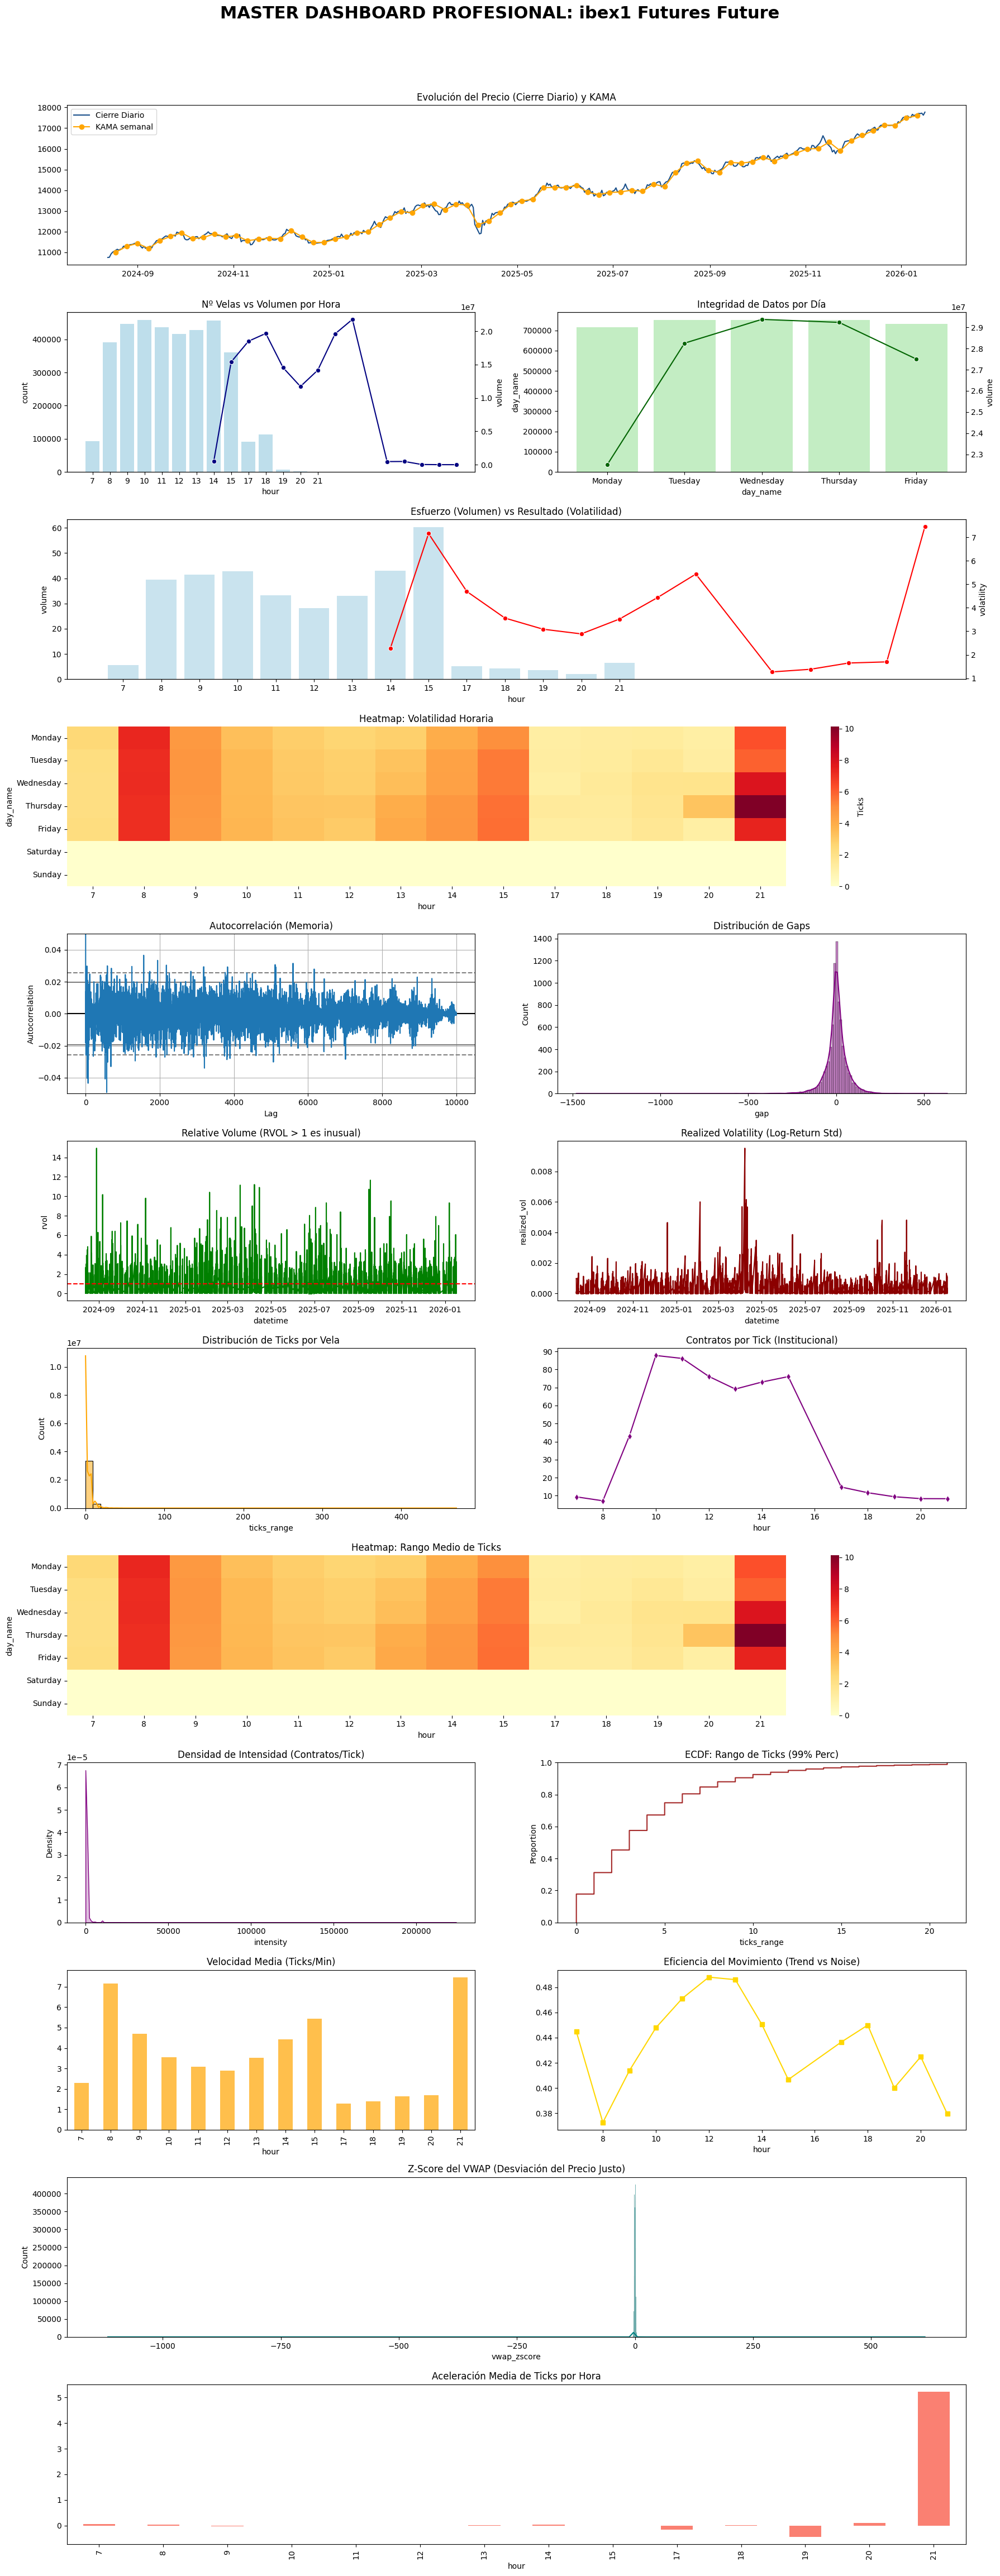

In [3]:
df_min, spec = import_dataset(asset=ASSET)
df_min_clean = clean(df_min, asset=ASSET, break_hour=spec['break_start'])
df_min_clean["close"] = wavelet_denoising(df_min_clean['close'].values.copy())
df_resampled = resample_ohlcv(df_min_clean, period=f"{MINUTES}min")
df_cumulative = daily_ohlcv_cummulative(df_resampled)
plot_master_market_analysis(df_min_clean, asset_name=f"{ASSET} Futures", tick_size=spec['tick_size'])

In [4]:
with open("../Data/features_config.json") as f:
    config = json.load(f)

config["global"]["sampling_minutes"] = MINUTES
config["global"]["return_horizon_min"] = RETURN_HORIZON_MIN
config["global"]["tick_size"] = spec["tick_size"]



In [5]:
df_final = generate_features(df_cumulative, config_json=config, dropna_strategy='any')

In [6]:
data_quality_report(df_final)

Data Quality Report
 - rows: 57972, cols: 151
 - top 20 NaN fractions:
datetime        0.0
open            0.0
high            0.0
low             0.0
close           0.0
volume          0.0
openint         0.0
dtyyyymmdd      0.0
ticker          0.0
per             0.0
trading_date    0.0
open_day        0.0
high_cum        0.0
low_cum         0.0
volume_cum      0.0
hour            0.0
minute          0.0
dayofweek       0.0
day             0.0
month           0.0
dtype: float64

Suggestions:
 - Drop or fix constant columns: ['openint', 'ticker', 'per', 'minute', 'minute_sin', 'minute_cos']
 - `rolling_slope` may be slow; consider vectorized replacement or numba.
 - To avoid fragmentation, build new columns in a dict and `pd.concat` once per group.


{'rows': 57972,
 'cols': 151,
 'na_fraction': {'datetime': 0.0,
  'open': 0.0,
  'high': 0.0,
  'low': 0.0,
  'close': 0.0,
  'volume': 0.0,
  'openint': 0.0,
  'dtyyyymmdd': 0.0,
  'ticker': 0.0,
  'per': 0.0,
  'trading_date': 0.0,
  'open_day': 0.0,
  'high_cum': 0.0,
  'low_cum': 0.0,
  'volume_cum': 0.0,
  'hour': 0.0,
  'minute': 0.0,
  'dayofweek': 0.0,
  'day': 0.0,
  'month': 0.0,
  'is_month_end': 0.0,
  'hour_sin': 0.0,
  'hour_cos': 0.0,
  'minute_sin': 0.0,
  'minute_cos': 0.0,
  'dow_sin': 0.0,
  'dow_cos': 0.0,
  'day_sin': 0.0,
  'day_cos': 0.0,
  'month_sin': 0.0,
  'month_cos': 0.0,
  'is_prev_break_hour': 0.0,
  'is_post_break_hour': 0.0,
  'is_NY_open_hour': 0.0,
  'week_of_month': 0.0,
  'seconds_since_midnight': 0.0,
  'session_progress': 0.0,
  'is_london': 0.0,
  'is_ny': 0.0,
  'is_overlap': 0.0,
  'sma_20': 0.0,
  'ema_20': 0.0,
  'dema': 0.0,
  'kama': 0.0,
  'ema_fast': 0.0,
  'ema_slow': 0.0,
  'macd': 0.0,
  'signal': 0.0,
  'histogram': 0.0,
  'rsi': 0.0,

In [7]:
df_final

,datetime,open,high,low,close,volume,openint,dtyyyymmdd,ticker,per,...,body_pct,upper_wick_pct,lower_wick_pct,close_location,dist_high_cum_ticks,dist_low_cum_ticks,dist_open_day_ticks,vol_per_tick,vol_vs_body,vol_weight_intraday
0,1993-01-15 12:00:00,2529.0,2535.0,2526.0,2530.576007,2810,0.0,1993-01-15,MFXI,60min,...,0.175112,0.491555,0.333333,0.508445,4.423993,20.576007,20.576007,281.000000,1090.835424,0.270426
1,1993-01-15 13:00:00,2529.0,2530.0,2525.0,2528.429701,3685,0.0,1993-01-15,MFXI,60min,...,0.114060,0.200000,0.685940,0.685940,6.570299,18.429701,18.429701,614.166667,2346.687399,0.261793
2,1993-01-15 14:00:00,2528.0,2533.0,2528.0,2532.179980,2490,0.0,1993-01-15,MFXI,60min,...,0.835996,0.164004,0.000000,0.835996,2.820020,22.179980,22.179980,415.000000,480.696842,0.150308
3,1993-01-15 15:00:00,2532.0,2547.0,2530.0,2540.660138,5825,0.0,1993-01-15,MFXI,60min,...,0.509420,0.372933,0.117647,0.627067,6.339862,30.660138,30.660138,323.611111,602.993437,0.260149
4,1993-01-15 16:00:00,2537.0,2548.0,2537.0,2548.342616,4257,0.0,1993-01-15,MFXI,60min,...,1.031147,-0.031147,0.000000,1.031147,-0.342616,38.342616,38.342616,354.750000,344.902581,0.159749
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57967,2026-01-16 18:00:00,17724.0,17740.0,17719.0,17733.130435,51,0.0,2026-01-16,MFXI,60min,...,0.434783,0.327122,0.238095,0.672878,6.869565,113.130435,67.130435,2.318182,5.034335,0.012668
57968,2026-01-16 19:00:00,17736.0,17755.0,17727.0,17747.888571,25,0.0,2026-01-16,MFXI,60min,...,0.424592,0.253980,0.321429,0.746020,7.111429,127.888571,81.888571,0.862069,1.939703,0.006171
57969,2026-01-16 20:00:00,17747.0,17755.0,17733.0,17744.701625,29,0.0,2026-01-16,MFXI,60min,...,0.104472,0.363636,0.531892,0.531892,10.298375,124.701625,78.701625,1.260870,8.792208,0.007108
57970,2026-01-16 21:00:00,17746.0,17769.0,17746.0,17763.369149,36,0.0,2026-01-16,MFXI,60min,...,0.755180,0.244820,0.000000,0.755180,5.630851,143.369149,97.369149,1.500000,1.959808,0.008746
